# 03 — Would a model trained through 2022 have seen Silicon Valley Bank coming?

Silicon Valley Bank (CERT 24735) failed on 10 March 2023, Signature Bank (57053) two days
later and First Republic Bank (59017) on 1 May 2023: the three largest failures since
2008, and none of them a credit story. Their loans were performing. What sank them was
the other side of the balance sheet: long-dated securities bought at 2020-2021 yields
that had lost a large share of their value after the 2022 rate rises, funded by deposits
that were mostly above the $250,000 insurance limit and could leave in an afternoon.

This notebook asks the question the project was built around: with strict point-in-time
discipline, would a model trained on everything known by the 2022Q4 prediction date have
ranked these three banks near the top? Two *views* are fitted with the same two learners:

- **credit-only**: the 43 Prototype 1 `features_v1` ratios (capital, asset quality,
  earnings, funding, concentrations, size);
- **rate-aware**: all 83 `features_v2` columns, which add unrealised securities losses
  relative to Tier 1 capital, the uninsured-deposit share, the trend and persistence
  blocks and the macro rates.

The learners are the Prototype 1 regularised logit (`LOGIT_C`, chosen on a validation
slice inside 2002-2008) and the production booster `gbdt_mono`: the tuned
`settings.models.gbdt` parameters under the feature registry's monotone signs, which
Decision Point 2 made the production model. Nothing is re-tuned on 2022-2023 data.

## 1. Training rows: windows closed before 1 March 2023

The prediction date of a 2022Q4 report is 2023-03-01 (report date plus the 60-day
availability lag). Rule 6.2 keeps a training row only if its 4-quarter outcome window
had already closed on that date, which `bankcanary.splits.training_mask` enforces and
`assert_no_leakage` re-checks on the selected rows: the last usable report is 2021Q3.
The fitted models then score the 2022Q3, 2022Q4 and 2023Q1 reports of every bank.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "config" / "settings.yaml").exists() else Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from bankcanary.config import load_settings
from bankcanary.evaluation import case_study_2023 as cs

settings = load_settings()
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 100
frame = cs.load_frame(settings)
train = cs.training_rows(frame, settings)
scored = cs.scoring_rows(frame)
print(f"{len(frame):,} bank-quarters in features_v2")
tr = frame.loc[train, "repdte"]
print(f"training rows: {int(train.sum()):,} ({int(frame.loc[train, 'y_4q'].sum()):,} failures), "
      f"reports {tr.min():%Y-%m-%d} to {tr.max():%Y-%m-%d}")
quarters = sorted(frame.loc[scored, "repdte"].dt.strftime("%Y-%m-%d").unique())
print(f"scored rows: {int(scored.sum()):,} over {quarters}")
frame.loc[frame["cert"].isin(cs.BANKS) & scored, ["cert", "repdte", "name", "asset", "fail_date"]]

710,691 bank-quarters in features_v2
training rows: 622,341 (2,226 failures), reports 2001-03-31 to 2021-09-30
scored rows: 14,326 over ['2022-09-30', '2022-12-31', '2023-03-31']


,cert,repdte,name,asset,fail_date
452765,24735,2022-09-30,SILICON VALLEY BANK,210244000.0,2023-03-10
452766,24735,2022-12-31,SILICON VALLEY BANK,209026000.0,2023-03-10
641214,57053,2022-09-30,SIGNATURE BANK,114468746.0,2023-03-12
641215,57053,2022-12-31,SIGNATURE BANK,110363650.0,2023-03-12
702628,59017,2022-09-30,FIRST REPUBLIC BANK,205108685.0,2023-05-01
702629,59017,2022-12-31,FIRST REPUBLIC BANK,212638872.0,2023-05-01
702630,59017,2023-03-31,FIRST REPUBLIC BANK,232944161.0,2023-05-01


## 2. Four fits, three banks, three quarters

`run_case_study` fits `logit` and `gbdt_mono` on each view (about 30 seconds in total, no
subsampling needed) and ranks every scored bank within its quarter: rank 1 is the
riskiest bank, the percentile is the share of scored banks ranked below it. Each fit is
logged as a run record under `runs/case_study_2023/` with the split facts and the three
banks' ranks. SVB and Signature failed before filing a 2023Q1 report, so they have no
row in that quarter; First Republic's 2023Q1 report is scored although it was published
after the bank failed (it is the post-failure report the labels exclude from training).

In [2]:
study = cs.run_case_study(frame, settings)
report = cs.write_report(study, settings)
print("report:", report)
ranks = study.table.pivot_table(
    index=["bank", "quarter"], columns=["view", "model"], values="rank"
).astype("Int64")
ranks

report: /Users/batuhanisik/Desktop/Projects/bank-failure-early-warning/reports/svb_2023_case_study.md


view                        credit_only       rate_aware      
model                         gbdt_mono logit  gbdt_mono logit
bank                quarter                                   
First Republic Bank 2022Q3         1129  1760        734  2698
                    2022Q4         1207  1570        901  1750
                    2023Q1         1181   308        258   225
Signature Bank      2022Q3          998   172        491  1031
                    2022Q4         1279   113        564   627
Silicon Valley Bank 2022Q3         2600  2336       2106  3315
                    2022Q4         2149  1677       2368  1854

In [3]:
pct = study.table.pivot_table(
    index=["bank", "quarter"], columns=["view", "model"], values="percentile"
).round(1)
prob = study.table.pivot_table(
    index=["bank", "quarter"], columns=["view", "model"], values="probability"
)
print("Percentile (100 = riskiest bank of the quarter)")
display(pct)
print("Probability of failure within four quarters")
prob.map(lambda v: f"{v:.5f}" if pd.notna(v) else "")

Percentile (100 = riskiest bank of the quarter)


view                        credit_only       rate_aware      
model                         gbdt_mono logit  gbdt_mono logit
bank                quarter                                   
First Republic Bank 2022Q3         76.5  63.4       84.7  43.9
                    2022Q4         74.7  67.1       81.1  63.3
                    2023Q1         75.1  93.5       94.6  95.3
Signature Bank      2022Q3         79.3  96.4       89.8  78.6
                    2022Q4         73.2  97.6       88.2  86.9
Silicon Valley Bank 2022Q3         46.0  51.5       56.2  31.1
                    2022Q4         55.0  64.9       50.4  61.2

Probability of failure within four quarters


view                        credit_only          rate_aware         
model                         gbdt_mono    logit  gbdt_mono    logit
bank                quarter                                         
First Republic Bank 2022Q3      0.00012  0.00028    0.00023  0.00011
                    2022Q4      0.00012  0.00031    0.00022  0.00024
                    2023Q1      0.00012  0.00086    0.00039  0.00077
Signature Bank      2022Q3      0.00013  0.00106    0.00028  0.00023
                    2022Q4      0.00011  0.00140    0.00029  0.00046
Silicon Valley Bank 2022Q3      0.00007  0.00022    0.00012  0.00008
                    2022Q4      0.00008  0.00030    0.00011  0.00023

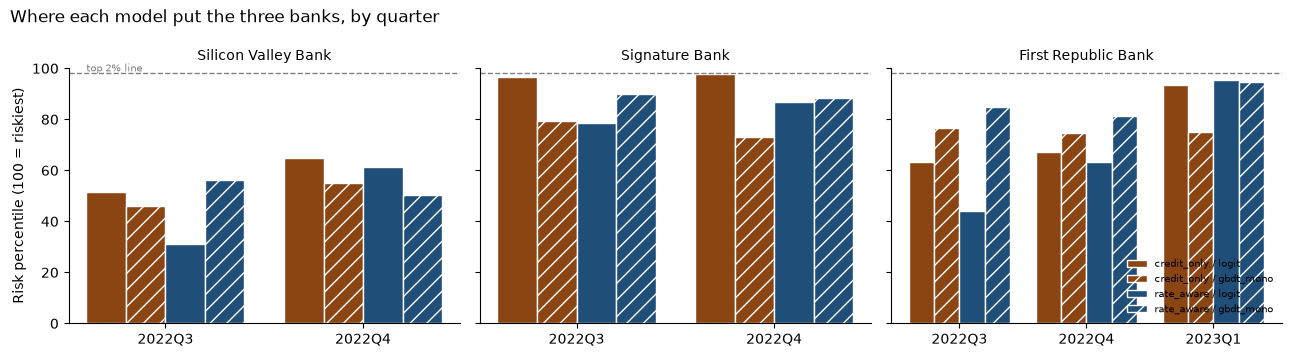

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
order = [(view, model) for view in cs.VIEWS for model in cs.MODELS]
colors = {"credit_only": "#8B4513", "rate_aware": "#1f4e79"}
hatch = {"logit": "", "gbdt_mono": "//"}
for ax, (cert, name) in zip(axes, cs.BANKS.items()):
    sub = study.table.loc[study.table["cert"].eq(cert)]
    quarters = sorted(sub["quarter"].unique())
    width = 0.8 / len(order)
    for i, (view, model) in enumerate(order):
        cell = sub.loc[sub["view"].eq(view) & sub["model"].eq(model)].set_index("quarter")
        x = np.arange(len(quarters)) + (i - 1.5) * width
        ax.bar(x, cell["percentile"].reindex(quarters).to_numpy(), width,
               color=colors[view], hatch=hatch[model], edgecolor="white", label=f"{view} / {model}")
    ax.axhline(98, color="grey", linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(len(quarters)), quarters)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(0, 100)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Risk percentile (100 = riskiest)")
axes[0].text(-0.4, 98.8, "top 2% line", fontsize=7, color="grey")
axes[-1].legend(fontsize=7, frameon=False, loc="lower right")
fig.suptitle("Where each model put the three banks, by quarter", x=0.01, ha="left")
plt.tight_layout()
plt.show()

## 3. What drove SVB's 2022Q4 score under each model

For the boosters the contributions are SHAP values from the tree explainer on the
winsorised inputs; for the logits they are coefficient times standardised value on the
pipeline's own winsorise-impute-scale output. Both sum to the bank's log-odds minus the
model's baseline (the expected log-odds for the booster, the intercept for the logit),
so positive bars push SVB towards failure and negative bars away from it.

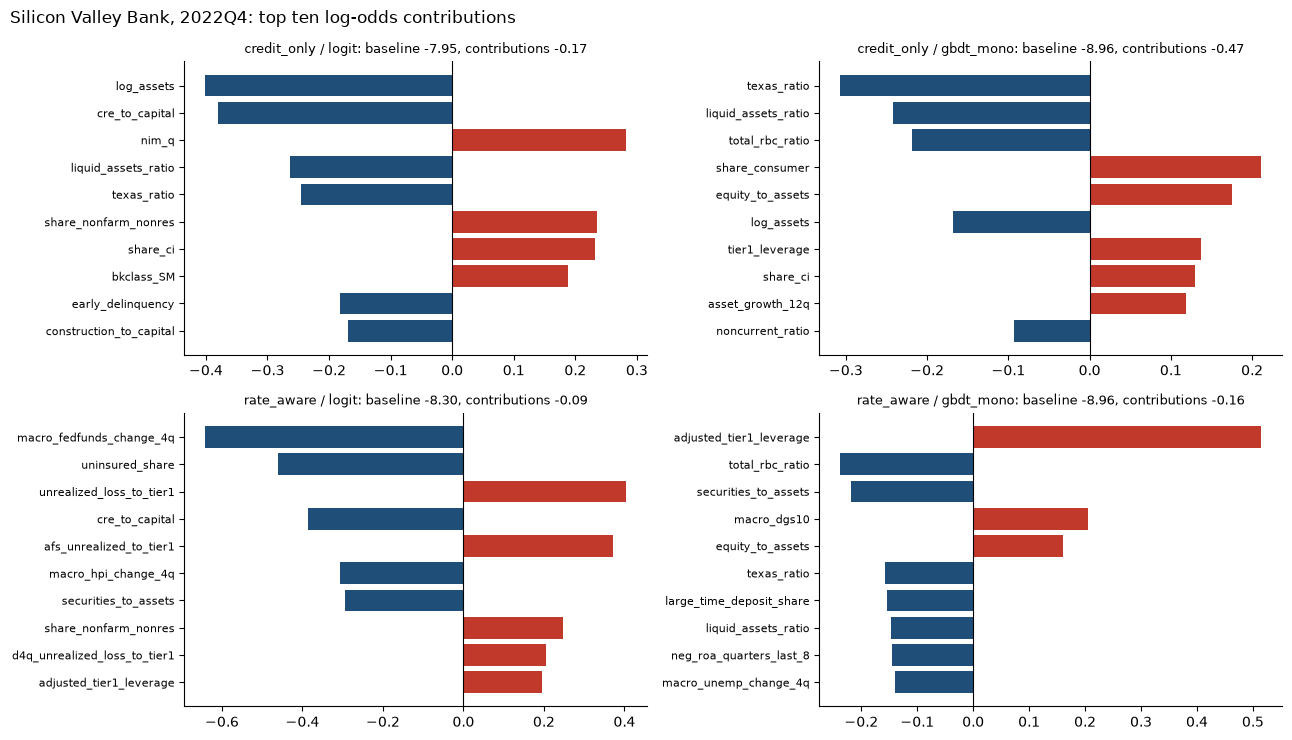

,feature,value,contribution,direction
0,adjusted_tier1_leverage,-0.330102,0.5144,riskier
1,total_rbc_ratio,16.050691,-0.2372,safer
2,securities_to_assets,0.56116,-0.2182,safer
3,macro_dgs10,3.92,0.2044,riskier
4,equity_to_assets,0.073943,0.1613,riskier
5,texas_ratio,0.008794,-0.1574,safer
6,large_time_deposit_share,0.008006,-0.1537,safer
7,liquid_assets_ratio,0.624396,-0.1472,safer
8,neg_roa_quarters_last_8,0.0,-0.1442,safer
9,macro_unemp_change_4q,-1.0,-0.1407,safer


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for ax, ((view, model), table) in zip(axes.ravel(), study.drivers.items()):
    top = table.iloc[::-1]
    color = np.where(top["contribution"] > 0, "#c0392b", "#1f4e79")
    ax.barh(top["feature"], top["contribution"], color=color)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"{view} / {model}: baseline {table.attrs['baseline']:.2f}, "
        f"contributions {table.attrs['total']:+.2f}",
        fontsize=9,
    )
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Silicon Valley Bank, 2022Q4: top ten log-odds contributions", x=0.01, ha="left")
plt.tight_layout()
plt.show()
study.drivers[("rate_aware", "gbdt_mono")].round(4)

In [6]:
study.drivers[("rate_aware", "logit")].round(4)

,feature,value,contribution,direction
0,macro_fedfunds_change_4q,4.49,-0.6408,safer
1,uninsured_share,0.864373,-0.4610,safer
2,unrealized_loss_to_tier1,-1.0406,0.4038,riskier
3,cre_to_capital,0.133848,-0.3874,safer
4,afs_unrealized_to_tier1,-0.148632,0.3725,riskier
5,macro_hpi_change_4q,0.131153,-0.3063,safer
6,securities_to_assets,0.56116,-0.2936,safer
7,share_nonfarm_nonres,0.023529,0.2473,riskier
8,d4q_unrealized_loss_to_tier1,-0.963866,0.2050,riskier
9,adjusted_tier1_leverage,-0.330102,0.1957,riskier


## 4. Unrealised losses and uninsured deposits against the large-bank peer group

`unrealized_loss_to_tier1` is the sum of unrealised gains and losses on
available-for-sale and held-to-maturity securities divided by Tier 1 capital (negative
means losses); `uninsured_share` is the share of deposits above the insurance limit. The
band is the 5th-95th percentile of every bank with more than $10 billion of assets,
2020Q1-2023Q1, and the line is its median.

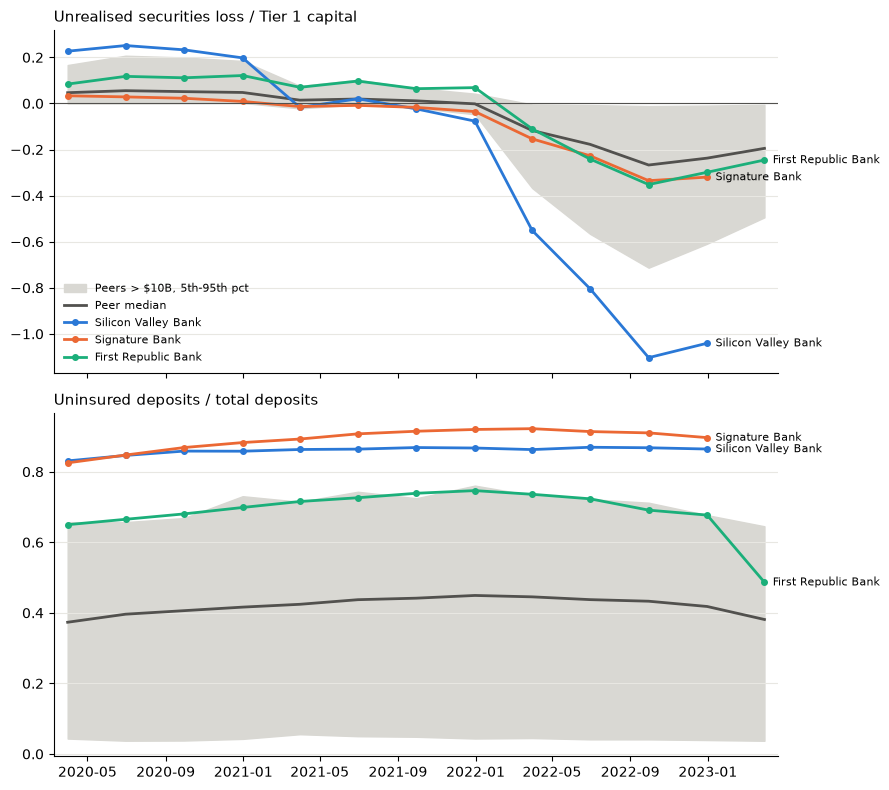

SVB 2022Q4: unrealized_loss_to_tier1 -1.0406, uninsured_share 0.8644, adjusted_tier1_leverage -0.3301, texas_ratio 0.0088, noncurrent_ratio 0.0019, equity_to_assets 0.0739, liquid_assets_ratio 0.6244


In [7]:
COLORS = {24735: "#2a78d6", 57053: "#eb6834", 59017: "#1baf7a"}
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
for ax, (col, title) in zip(axes, cs.CHART_FEATURES.items()):
    band = cs.peer_bands(frame, col)
    ax.fill_between(band.index, band[0.05], band[0.95], color="#d9d8d3",
                    label="Peers > $10B, 5th-95th pct")
    ax.plot(band.index, band[0.5], color="#52514e", lw=2, label="Peer median")
    for cert, name in cs.BANKS.items():
        rows = frame.loc[frame["cert"].eq(cert) & frame["repdte"].between(*cs.CHART_WINDOW)]
        s = rows.set_index("repdte")[col].dropna()
        ax.plot(s.index, s.to_numpy(), color=COLORS[cert], lw=2, marker="o", ms=4, label=name)
        ax.annotate(name, (s.index[-1], s.iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", fontsize=8, va="center")
    ax.set_title(title, loc="left", fontsize=11)
    ax.grid(axis="y", color="#e8e7e2", lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.02)
axes[0].axhline(0, color="#52514e", lw=0.8)
axes[0].legend(loc="lower left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()
svb = frame.loc[frame["cert"].eq(24735) & frame["repdte"].eq("2022-12-31")].iloc[0]
keys = ["unrealized_loss_to_tier1", "uninsured_share", "adjusted_tier1_leverage",
        "texas_ratio", "noncurrent_ratio", "equity_to_assets", "liquid_assets_ratio"]
print("SVB 2022Q4:", ", ".join(f"{k} {svb[k]:.4f}" for k in keys))

## 5. Why the credit-only view misses them, and what the rate-aware view adds

**The credit ratios looked fine.** At 2022Q4 SVB's Texas ratio was 0.009 and its
noncurrent ratio a few tenths of a percent, both well inside the healthy range, its
equity-to-assets 7.4 percent and its liquid-assets ratio 0.62. Every large credit-only
driver pushes it *towards* safety (`texas_ratio`, `liquid_assets_ratio`, `log_assets`);
the small positive contributions come from nonfarm-nonresidential and multifamily loan
shares. The credit-only models place it at the 55th-65th percentile: an ordinary bank.
First Republic reads the same way (67th-75th). Signature is the one exception, and for
a reason that has nothing to do with 2023: the credit-only logit ranks it 113th of
4,773 (97.6th percentile) on its C&I loan share, CRE at three times capital and its
multifamily book, which is the 2008-style concentration profile the model was trained
to fear. The monotone booster does not share that view (73rd percentile).

**What the rate-aware view adds, and where it falls short.** The `features_v2` columns
show what the credit ratios cannot: SVB's unrealised securities losses reached 104
percent of Tier 1 capital by 2022Q4 (`unrealized_loss_to_tier1` = -1.04, against a
median of -0.24 and a 5th percentile of -0.61 among banks above $10 billion), its
capital net of those losses was negative (`adjusted_tier1_leverage` = -0.33, where the
same peers sat between 2.9 and 11.1) and 86 percent of its deposits were uninsured. The
production booster sees the first of these: `adjusted_tier1_leverage` is SVB's largest
driver at +0.51 log-odds. But that is all it sees, and the rest of the balance sheet
pulls the other way (`total_rbc_ratio` 16.1, `securities_to_assets` 0.56, the Texas
ratio, a tiny large-time-deposit share, the liquid-assets ratio and eight quarters
without a loss together contribute -1.06), so SVB stays at rank 2,368 of 4,773 (50th
percentile, 23rd of the 39
banks above $100 billion). In the training years, negative capital net of securities
losses was rare (116 bank-quarters) and 55 of those banks failed. The unconstrained
booster of the earlier version of this notebook carved that pocket into a single leaf
worth +2.1 and lifted SVB to rank 245 (94.9th percentile); the monotone fit spreads the
effect of `adjusted_tier1_leverage` over its whole range instead, and the extreme value
at SVB earns a fifth of that. The logit cannot use it either: its coefficients are
averages over 2001-2021, when a high uninsured share marked large, well-run banks
(failed banks averaged 13 percent uninsured deposits, survivors 20 percent) and rising
policy rates marked calm years, so `uninsured_share` and `macro_fedfunds_change_4q`
enter with *safer* signs and offset the loss terms; the rate-aware logit leaves SVB at
the 61st percentile. The rate-aware booster does more for the other two banks:
Signature moves to rank 564 (88th percentile, second of the 39 banks above $100
billion, on its C&I share and the four-quarter change in unrealised losses) and First
Republic to rank 901 (81st; 258th, the 94.6th percentile, on its 2023Q1 report), and
over every scored report with a complete label it pools better than the other three
fits (PR-AUC 0.068 against 0.015-0.023, 13 failures). The honest summary is that the
rate-aware features move the production booster in the right direction for all three
banks but put none of them in the top 2 percent before they failed, that the one model
which did flag SVB on the mechanism that failed it was the unconstrained booster the
backtest rejected, and that the deposit-run side of the story is something no model
trained on 2001-2021 outcomes could have learned.

## 6. Caveats

- **Three banks.** This is a case study, not an evaluation: three events, chosen because
  they failed. The ranking metrics over the 14,326 scored reports (13 complete-label
  failures) are printed in the report for context only.
- **In-sample by construction.** The models were fit through the 2022Q4 prediction date
  and never see the 2023 outcomes, so the scores are point-in-time; but the cut, the
  three banks and the features to look at were chosen knowing what happened. The
  walk-forward backtest of notebook 02 is the out-of-sample evidence.
- **The hyper-parameters are the 2002-2008 ones.** `LOGIT_C` and the booster settings
  were tuned on the P1 fixed split (rule 6.7) and reused unchanged. The booster shown is
  the production configuration (`settings.models.gbdt.monotone = true`, Decision Point
  2); the unconstrained `gbdt` stays available through `cs.build_model` for comparison,
  and its rank 245 for SVB against the monotone fit's 2,368 is the clearest example of
  what the constraints give up in exchange for a stable score scale across years.
- **Probabilities stay small.** Even SVB's rate-aware booster score is 0.0001: the
  models rank, they do not sound an alarm, and the value of the case study is the rank.
- **The labels' 2023Q1 gap.** SVB and Signature never filed a 2023Q1 report; First
  Republic's is a post-failure filing and is scored but was never in any training set.